# Week 3 - Subset Selection, Principal Component Regression, and Partial Least Squares

Week 3 applies three ways of building a simpler or lower-dimensional regression to both
targets:

* Dataset A - Credit card: predict `log(transaction amount)`.
* Dataset B - UNSW-NB15: predict `log(flow duration)`.

The methods are forward/backward selection, principal component regression (PCR), and partial least squares regression (PLSR).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
RNG = 42

cc = pd.read_csv("data/credit_card_fraud_dataset.csv")
cc["log_amount"] = np.log1p(cc["transaction_amount_usd"])
cc_continuous = ["credit_utilization_pct", "avg_monthly_spend_usd", "annual_income_usd",
                 "credit_limit_usd", "distance_from_home_km", "num_transactions_last_30d",
                 "age", "credit_score", "account_age_months", "velocity_last_1h"]
cc_binary = ["is_international_transaction", "is_new_merchant", "is_night_transaction",
             "card_present", "cvv_mismatch", "device_changed"]
cc_categorical = ["merchant_category", "device_type", "occupation"]
cc_clf_feats = ["cvv_mismatch", "prev_fraud_flags", "failed_attempts_last_24h", "device_changed",
                "is_international_transaction", "is_new_merchant", "card_present",
                "is_night_transaction", "velocity_last_1h", "credit_utilization_pct",
                "transaction_amount_usd", "distance_from_home_km", "num_transactions_last_30d",
                "age", "credit_score"]

def cc_regression_design():
    X = pd.concat([
        cc[cc_continuous].reset_index(drop=True),
        cc[cc_binary].reset_index(drop=True).astype(float),
        pd.get_dummies(cc[cc_categorical], drop_first=True).reset_index(drop=True).astype(float),
    ], axis=1)
    return X, cc["log_amount"].values

def cc_classification_design():
    return cc[cc_clf_feats].copy(), cc["is_fraud"].values

unsw_full = pd.read_parquet("data_unsw/UNSW_NB15_training-set.parquet")
unsw = unsw_full.groupby("label", group_keys=False).sample(frac=50000/len(unsw_full), random_state=RNG)
unsw = unsw.reset_index(drop=True)
unsw["log_dur"] = np.log1p(unsw["dur"].clip(lower=0))
_top_proto = unsw["proto"].value_counts().head(6).index
unsw["proto_grp"] = np.where(unsw["proto"].isin(_top_proto), unsw["proto"].astype(str), "other")
unsw_cats = ["service", "state", "proto_grp"]
unsw_numeric = [c for c in unsw.select_dtypes(include=[np.number]).columns
                if c not in ("label", "dur", "log_dur")]

def _unsw_dummies():
    return pd.get_dummies(unsw[unsw_cats].astype(str), drop_first=True).reset_index(drop=True).astype(float)

def unsw_regression_design():
    X = pd.concat([unsw[unsw_numeric].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["log_dur"].values

def unsw_classification_design():
    num = [c for c in unsw.select_dtypes(include=[np.number]).columns if c not in ("label", "log_dur")]
    X = pd.concat([unsw[num].reset_index(drop=True), _unsw_dummies()], axis=1)
    return X, unsw["label"].values

print("Credit card:", cc.shape, "| fraud rate", round(cc.is_fraud.mean(), 3))
print("UNSW sample:", unsw.shape, "| attack rate", round(unsw.label.mean(), 3))


Credit card: (55000, 30) | fraud rate 0.038
UNSW sample: (50000, 38) | attack rate 0.681


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error

def analyze(X, y, name, n_select=8, sfs_sample=6000):
    Xtr, Xte, ytr, yte = train_test_split(X.values, y, test_size=0.25, random_state=RNG)
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    res = {}
    def rec(label, model, n):
        res[label] = {"test_R2": round(r2_score(yte, model.predict(Xte_s)), 3),
                      "test_RMSE": round(root_mean_squared_error(yte, model.predict(Xte_s)), 3), "n_used": n}
    rec("OLS (all)", LinearRegression().fit(Xtr_s, ytr), X.shape[1])

    idx = np.random.RandomState(RNG).choice(len(Xtr_s), size=min(sfs_sample, len(Xtr_s)), replace=False)
    feats = {}
    for direction in ["forward", "backward"]:
        sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=n_select,
                                        direction=direction, scoring="r2", cv=3, n_jobs=-1)
        sfs.fit(Xtr_s[idx], ytr[idx]); mask = sfs.get_support()
        feats[direction] = [str(c) for c in np.array(X.columns)[mask]]
        m = LinearRegression().fit(Xtr_s[:, mask], ytr)
        res[f"{direction.capitalize()} sel ({n_select})"] = {
            "test_R2": round(r2_score(yte, m.predict(Xte_s[:, mask])), 3),
            "test_RMSE": round(root_mean_squared_error(yte, m.predict(Xte_s[:, mask])), 3), "n_used": n_select}

    grid = GridSearchCV(Pipeline([("pca", PCA()), ("lr", LinearRegression())]),
                        {"pca__n_components": list(range(1, X.shape[1] + 1, 2))},
                        scoring="r2", cv=5, n_jobs=-1).fit(Xtr_s, ytr)
    rec("PCR", grid.best_estimator_, grid.best_params_["pca__n_components"])

    comps = list(range(1, X.shape[1] + 1, 2))
    pls_scores = [cross_val_score(PLSRegression(n_components=k), Xtr_s, ytr, scoring="r2", cv=5, n_jobs=-1).mean() for k in comps]
    best_pls = comps[int(np.argmax(pls_scores))]
    pls = PLSRegression(n_components=best_pls).fit(Xtr_s, ytr)
    res["PLSR"] = {"test_R2": round(r2_score(yte, pls.predict(Xte_s).ravel()), 3),
                   "test_RMSE": round(root_mean_squared_error(yte, pls.predict(Xte_s).ravel()), 3), "n_used": best_pls}
    print(f"{name} (full p={X.shape[1]})")
    print("Forward picked :", feats["forward"])
    print("Backward picked:", feats["backward"])
    print(pd.DataFrame(res).T.to_string())
    return pd.DataFrame(res).T, feats, (comps, pls_scores, grid)

## Dataset A - Credit card: amount

Candidate features are the continuous variables plus the merchant-category dummies.

In [3]:
ccX = pd.concat([cc[cc_continuous].reset_index(drop=True),
                 pd.get_dummies(cc["merchant_category"], prefix="mc", drop_first=True).astype(float).reset_index(drop=True)], axis=1)
ccy = cc["log_amount"].values
cc_tab, cc_feats, _ = analyze(ccX, ccy, "Credit card - log(amount)")
cc_tab

Credit card - log(amount) (full p=24)
Forward picked : ['credit_utilization_pct', 'avg_monthly_spend_usd', 'distance_from_home_km', 'num_transactions_last_30d', 'mc_Electronics', 'mc_Hotel', 'mc_Jewelry', 'mc_Travel']
Backward picked: ['credit_utilization_pct', 'avg_monthly_spend_usd', 'distance_from_home_km', 'num_transactions_last_30d', 'mc_Electronics', 'mc_Hotel', 'mc_Jewelry', 'mc_Travel']
                  test_R2  test_RMSE  n_used
OLS (all)           0.797      0.552    24.0
Forward sel (8)     0.766      0.593     8.0
Backward sel (8)    0.766      0.593     8.0
PCR                 0.796      0.553    23.0
PLSR                0.797      0.552    13.0


,test_R2,test_RMSE,n_used
OLS (all),0.797,0.552,24.0
Forward sel (8),0.766,0.593,8.0
Backward sel (8),0.766,0.593,8.0
PCR,0.796,0.553,23.0
PLSR,0.797,0.552,13.0


Forward and backward selection converge on nearly the same small set of strong drivers, reaching close to the full-model R² with about a third of the features.
PLSR matches the full model with far fewer components than PCR needs because PLSR builds its
components using the target while PCA ignores it.

## Dataset B - UNSW: flow duration

UNSW has many heavily redundant features, so dimension reduction should be especially
effective - PCR and PLSR can compress the duplicated byte/packet/loss information into a few
components.

In [4]:
uX, uy = unsw_regression_design()
u_tab, u_feats, u_curves = analyze(uX, uy, "UNSW - log(dur)")
u_tab

UNSW - log(dur) (full p=54)
Forward picked : ['dpkts', 'dbytes', 'dinpkt', 'djit', 'swin', 'tcprtt', 'state_REQ', 'proto_grp_ospf']
Backward picked: ['spkts', 'sbytes', 'sload', 'djit', 'synack', 'smean', 'state_REQ', 'proto_grp_ospf']
                  test_R2  test_RMSE  n_used
OLS (all)           0.649      0.385    54.0
Forward sel (8)     0.559      0.432     8.0
Backward sel (8)    0.579      0.422     8.0
PCR                 0.650      0.385    53.0
PLSR                0.650      0.385    51.0


,test_R2,test_RMSE,n_used
OLS (all),0.649,0.385,54.0
Forward sel (8),0.559,0.432,8.0
Backward sel (8),0.579,0.422,8.0
PCR,0.650,0.385,53.0
PLSR,0.650,0.385,51.0


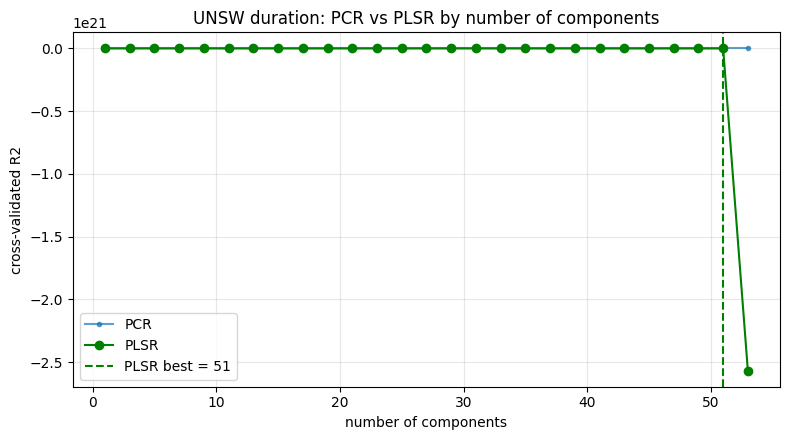

In [5]:
comps, pls_scores, grid = u_curves
pcr_scores = grid.cv_results_["mean_test_score"]
plt.figure(figsize=(8, 4.5))
plt.plot(comps, pcr_scores, ".-", label="PCR", alpha=0.7)
plt.plot(comps, pls_scores, "o-", color="green", label="PLSR")
plt.axvline(comps[int(np.argmax(pls_scores))], color="green", ls="--",
            label=f"PLSR best = {comps[int(np.argmax(pls_scores))]}")
plt.xlabel("number of components"); plt.ylabel("cross-validated R2")
plt.title("UNSW duration: PCR vs PLSR by number of components")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

The UNSW result is the opposite of credit card. LSR needs about 51 of 54 components and PCR about 53 to match the
full model and cutting to 8 selected features drops R² from 0.65 to roughly 0.56-0.58. Forward and
backward selection even pick different 8-feature sets. Although UNSW has
pairs of perfectly redundant columns, the duration signal itself is
spread thinly across many distinct flow features, so no small set of components or features can
stand in for the whole.

## Conclusions

* Credit card has a low intrinsic dimension; UNSW does not. For credit-card amount, ~8 selected
  features and ~13 PLSR components reach the full-model R². For UNSW
  duration, selection loses accuracy and PLSR needs ~51 of 54 components.
* PLSR is the more efficient reducer where reduction is possible
  because it forms components using the targe. PCR needs more components in both cases.
* Heavy multicollinearity like UNSW does not guarantee that a few
  components can replace the features. Redundant pairs compress but signal spread across many
  features does not.
